# Predictive Anayltics: Support Vector Machines

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib as plt
import datetime
from sklearn.svm import SVC 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

## Preparations

In [2]:
# "Settings" / Decisions for the training data

DATA_PATH = "../data/processed_data/gold_taxi.parquet"
# TRAINING_DATA_PATH = "../data/train_test_data/train.parquet"
# VAL_DATA_PATH = "../data/train_test_data/val.parquet"

MODEL_PATH = "../models"

# Target and feature selection
TARGET_COL = "trip_count"
EXCLUDE_COLS = [
    TARGET_COL,
    "datetime_hour",      # real timestamp would lead to much leakage
    "_split_bucket",      # only used for splitting
    "month", # cyclic feature is used instead
    "weekday", # cyclic feature is used instead
    "hour", # cyclic feature is used instead
    # all other taxi data columns must be excluded to prevent leakage
    "trip_seconds_sum",
    "trip_seconds_mean",
    "trip_seconds_min",
    "trip_seconds_max",
    "trip_miles_sum",
    "trip_miles_mean",
    "trip_miles_min",
    "trip_miles_max",
    "fare_sum",
    "fare_mean",
    "fare_min",
    "fare_max",
    "tips_sum",
    "tips_mean",
    "tips_min",
    "tips_max",
    "tolls_sum",
    "tolls_mean",
    "tolls_min",
    "tolls_max",
    "extras_sum",
    "extras_mean",
    "extras_min",
    "extras_max",
    "trip_total_sum",
    "trip_total_mean",
    "trip_total_min",
    "trip_total_max",
    "most_common_payment_type",
]

Load data and select features and target

In [11]:
# Load data
df = pl.scan_parquet(DATA_PATH)

# Split
train = df.filter(
    pl.col("trip_start_timestamp") < pl.datetime(2026, 1, 1)
)

val = df.filter(
    (pl.col("trip_start_timestamp") >= pl.datetime(2026, 1, 1)) &
    (pl.col("trip_start_timestamp") < pl.datetime(2026, 4, 1))
)

test = df.filter(
    pl.col("trip_start_timestamp") >= pl.datetime(2026, 4, 1)
)

train_df = train.collect()
val_df = val.collect()
test_df = test.collect()

print(train_df["trip_start_timestamp"].min(), train_df["trip_start_timestamp"].max())
print(val_df["trip_start_timestamp"].min(), val_df["trip_start_timestamp"].max())
print(test_df["trip_start_timestamp"].min(), test_df["trip_start_timestamp"].max())

2024-01-01 00:00:00 2025-12-31 23:45:00
2026-01-01 00:00:00 2026-03-31 23:45:00
2026-04-01 00:00:00 2026-04-30 23:45:00


In [ ]:
# Create X and Y data
feature_cols = [
    col for col in train_df.collect_schema().names()
    if col not in EXCLUDE_COLS
]

X_train = train_df.select(feature_cols).collect()
y_train = train_df.select(TARGET_COL).collect()

X_val = val_df.select(feature_cols).collect()
y_val = val_df.select(TARGET_COL).collect()

print("Features: ", X_train.schema)
print("Target: ", y_train.schema)

FileNotFoundError: The system cannot find the file specified. (os error 2): ../data/train_test_data/train.parquet

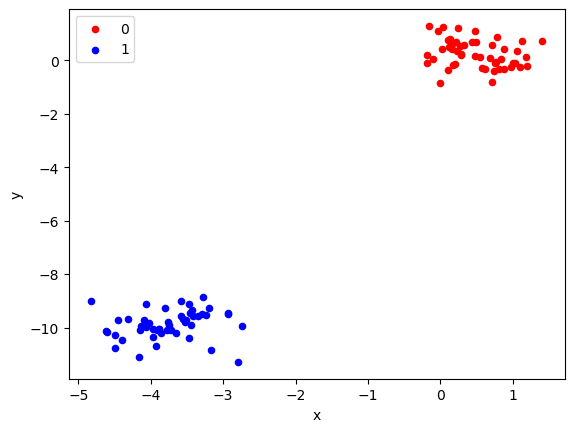

In [ ]:
# generate 2d classification dataset
X, y = make_blobs(n_samples=100, centers=2, n_features=2, cluster_std=0.5)
visualize(X,y)

# Split data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [ ]:
# Train SVC 
model = SVC()
model.fit(X_train, y_train)

SVC()

In [ ]:
# Make prediction 
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1])

In [ ]:
# Evaluate Model
print(confusion_matrix(y_test,y_pred))

print(classification_report(y_test,y_pred))

[[ 8  0]
 [ 0 12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
# get support vectors
model.support_vectors_

array([[-1.53745194e-01,  1.29405829e+00],
       [ 7.18746403e-01, -8.09639306e-01],
       [-2.39138636e-03, -8.38817303e-01],
       [-2.80132784e+00, -1.12880063e+01],
       [-3.27599890e+00, -8.86878913e+00],
       [-4.16705662e+00, -1.11095444e+01]])